In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import jax.numpy as jnp
import arviz as az
import numpy as np
import xarray as xr

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data
from cppp.utils import concat_log_likelihoods


/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model results (10 June 2026)
## Before running this notebook

### 1. Model fitting
Run `fit_multisensory.py` for each participant and each model ("optimal", "no_integration", "equal_integration"), e.g.
```bash
python fit_multisensory.py --participant 135033060 --model optimal --model_class MultisensoryDelayModelPointMassDynamics
```

You can also specify a model class (e.g. `MultisensoryDelayModelPointMassDynamics` for the version with more realistic hand movement dynamics)

### 2. Model simulation
After fitting the models to the data from the baseline phase, we can simulate behaviour in the offset phase. For each participant run `simulate_multisensory.py`, e.g.
```bash
python simulate_multisensory.py --participant 135033060 --model_class MultisensoryDelayModelPointMassDynamics
```

## Load model fits

Load the model fit files for all three models for a single example participant

In [3]:
participants = load_multisensory_data(base_path="../data")["participant"].unique()

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


In [4]:
def load_model(participant, model_name, seed=7453, num_warmup=1000):

    model = az.from_netcdf(
            f"../results/multisensory-mcmc-{participant}_1_2_{seed}_{num_warmup}_2500_4_{model_name}_MultisensoryDelayModelPointMassDynamics.nc"
        )
    return model


summaries = []
loos = []
for participant in participants:
    # define the model names to load
    model_names = [
        "optimal", "equal_integration", "no_integration",
    ]

    # dict for model comparisons
    models = {}

    # load the models for this participant
    for model_name in model_names:
        seed = 7453
        model = load_model(participant, model_name, seed=seed)
            
        if az.summary(model)["r_hat"].max() > 1.05:
            print(f"Model {model_name} for participant {participant} with seed {seed} has r_hat > 1.05, trying next seed.")

        summary = az.summary(model)

        # stack up log likelihoods for all 6 conditions into a single array for each model so that we can perform model comparison using all conditions together
        model = concat_log_likelihoods(model)
        # put model into dict
        models[model_name] = model

        # add the model name and participant to the summary dataframe
        summary["model"] = model_name
        summary["participant"] = participant
        summary["seed"] = seed
        summaries.append(summary)

        # compute the Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO) for the model
        loo = az.loo(model)
        loo["model"] = model_name
        loo["participant"] = participant
        loos.append({
            "participant": participant,
            "model": model_name,
            "elpd_loo": loo.elpd_loo,
            "se": loo.se,
        })

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-propri

In [5]:
df = pd.concat(summaries).reset_index().rename(columns={"index": "parameter"})
df


,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,model,participant,seed
0,action_cost,0.000,0.000,0.000,0.000,0.000,0.000,12068.0,7838.0,1.0,optimal,135033060,7453
1,action_variability,0.090,0.001,0.089,0.091,0.000,0.000,13088.0,8055.0,1.0,optimal,135033060,7453
2,sigma_prop,2.510,0.059,2.401,2.623,0.001,0.001,12371.0,7719.0,1.0,optimal,135033060,7453
3,sigma_vis[0],5.204,0.292,4.682,5.762,0.003,0.003,11308.0,7844.0,1.0,optimal,135033060,7453
4,sigma_vis[1],11.631,0.817,10.084,13.123,0.007,0.008,12221.0,7867.0,1.0,optimal,135033060,7453
...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,action_cost,0.000,0.000,0.000,0.000,0.000,0.000,11613.0,8427.0,1.0,no_integration,918338248,7453
281,action_variability,0.239,0.002,0.235,0.244,0.000,0.000,11447.0,8757.0,1.0,no_integration,918338248,7453
282,sigma_prop,2.344,0.083,2.188,2.500,0.001,0.001,11261.0,6902.0,1.0,no_integration,918338248,7453
283,sigma_vis[0],3.584,0.297,3.028,4.133,0.003,0.003,10106.0,7103.0,1.0,no_integration,918338248,7453


In [7]:
loo_df = pd.DataFrame(loos)
loo_df

,participant,model,elpd_loo,se
0,135033060,optimal,-12586.441833,284.666416
1,135033060,equal_integration,-12796.729599,287.813687
2,135033060,no_integration,-12553.403259,280.894307
3,173058413,optimal,-25263.122955,261.969566
4,173058413,equal_integration,-25273.512360,262.360256
5,173058413,no_integration,-25262.763947,261.952898
6,177196795,optimal,-13775.805801,425.638792
7,177196795,equal_integration,-13820.555466,424.897921
8,177196795,no_integration,-13670.689880,417.046739
9,182095555,optimal,-18081.732758,426.729493


In [10]:

short_model_name = {
    "optimal": "Optimal integration",
    "equal_integration":                  "Equal integration",
    "no_integration":                  "No integration",
}

loo_df["model_short"] = loo_df["model"].map(short_model_name)
df["model_short"] = df["model"].map(short_model_name)

model_order = ["Optimal integration", "Equal integration", "No integration"]
palette     = dict(zip(model_order, sns.color_palette("colorblind", 4)))

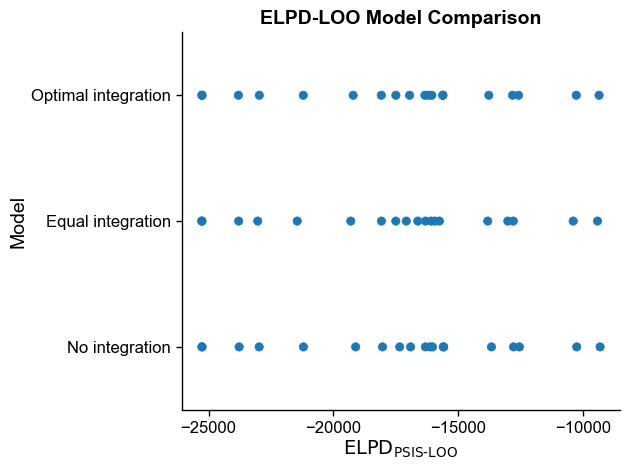

In [22]:
g = (so.Plot(loo_df, y="model_short", x="elpd_loo")
      .add(so.Dot())
    #   .add(so.Range())
      # .add(so.Dot(pointsize=2), so.Jitter())
      .scale(y=so.Nominal(order=model_order),
             x=so.Continuous().tick(upto=4))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Model", title="ELPD-LOO Model Comparison")
      .show()
)

/tmp/ipykernel_4035180/688741689.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


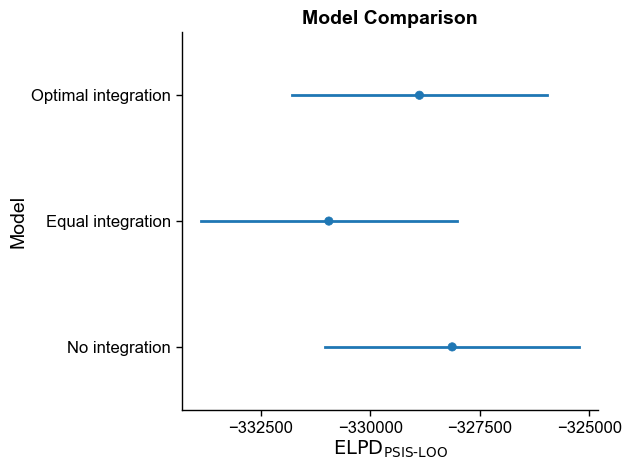

In [21]:
# sum up ELPDs across participants for each model, and compute the standard error of the sum
group_stats = (
    loo_df.groupby("model_short")
    .apply(lambda x: pd.Series({
        "elpd_loo_sum": x["elpd_loo"].sum(),
        "se_sum": np.sqrt((x["se"] ** 2).sum()),
    }))
    .reindex(model_order)
    .reset_index()
)

# compute the lower and upper bounds of ELPD 95 % CIs (+- 1.96 * se) of the ELPD-LOO sum for each model
group_stats["elpd_low"] = group_stats["elpd_loo_sum"] - 1.96 * group_stats["se_sum"]
group_stats["elpd_high"] = group_stats["elpd_loo_sum"] + 1.96 * group_stats["se_sum"]

g = (so.Plot(group_stats, y="model_short", x="elpd_loo_sum")
      .add(so.Dot())
      .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .scale(y=so.Nominal(order=model_order),
             x=so.Continuous().tick(upto=4))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Model", title="Model Comparison")
      .show()
)

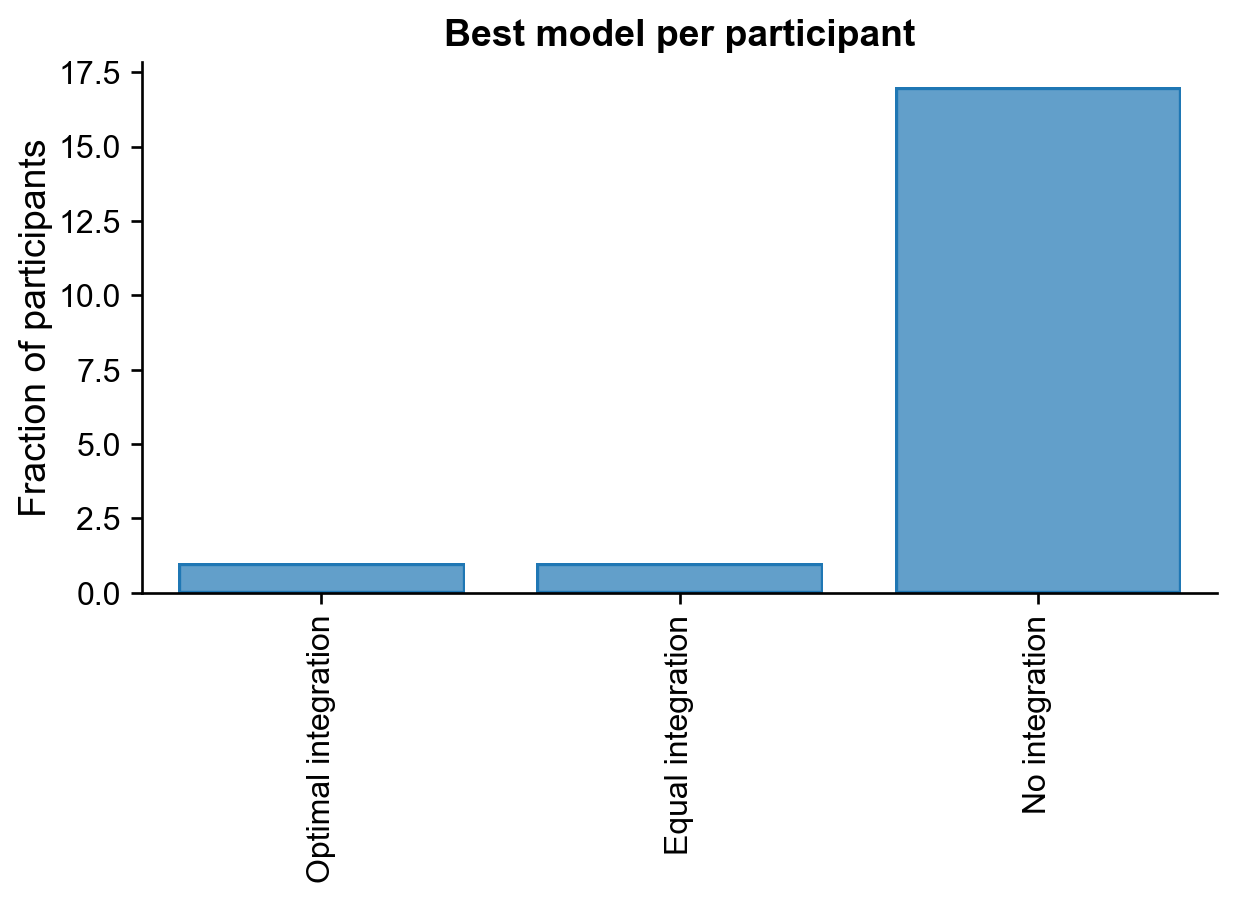

In [12]:
best_per_participant = (
    loo_df.loc[loo_df.groupby("participant")["elpd_loo"].idxmax(), ["model_short", "participant"]]
)

win_counts = (
    best_per_participant["model_short"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["model_short", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

g = (
    so.Plot(win_counts, x="model_short", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal(order=model_order))
    .label(x="", y="Fraction of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g

## Show parameter estimates

Parameter estimates for the following parameters
- visual noise (`sigma_vis`) in the low (1) and high (2) visual noise condition
- proprioceptive noise (`sigma_prop`)
- action variability (`action_variability`)
- action cost (`action_cost`)
compared across the three models

In [13]:
param_names = {"sigma_prop": "Proprioceptive", "sigma_vis[0]": "Visual (cursor)", "sigma_vis[1]": "Visual (blob)",
               "action_variability": "Action variability", "action_cost": "Action cost"}

In [14]:
# get the parts of df that correspond to the best model for each participant
best_model_params = df.merge(best_per_participant, on=["participant", "model_short"])
best_model_params["parameter"] = best_model_params["parameter"].map(lambda x: param_names.get(x, x))
df["parameter"] = df["parameter"].map(lambda x: param_names.get(x, x))


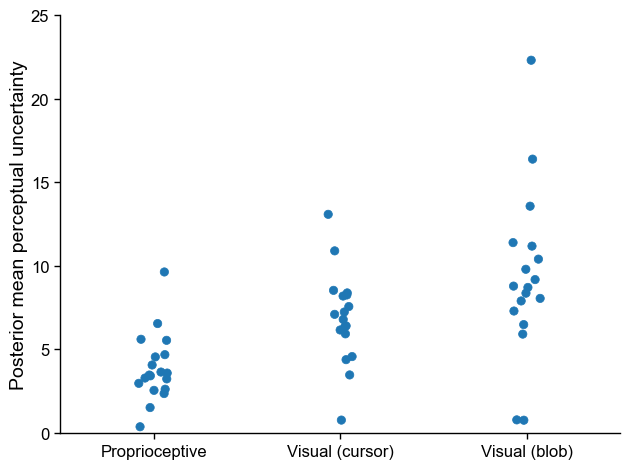

In [24]:


g = (
    so.Plot(
        best_model_params[
            (
                best_model_params["parameter"].isin(
                    ["Proprioceptive", "Visual (cursor)", "Visual (blob)"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="model_short",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    .limit(y=(0, 25.0))
    .label(x="", y="Posterior mean perceptual uncertainty")
    .scale(color=so.Nominal())
    # .facet(col="parameter")
    # .share(y=False)
)
g.show()

## Model comparison

Use Pareto-smoothed importance sampling approximation to leave-one-out cross-validation (PSIS-LOO), implemented in `arviz` (https://python.arviz.org/en/v0.22.0/api/generated/arviz.loo.html) and described by Vehtari et al. (2017, https://link.springer.com/article/10.1007/S11222-016-9696-4).

I have now stacked the data from all conditions together, so that we can get a single model comparison score for each participant using all of their baseline phase data.

## Load data

Load data from all participants and compute tracking error

In [6]:
df = load_multisensory_data(base_path="../data")

df["tracking_error"] = df["lefty_pos"] - df["righty_pos"]

df["offset_sign"] = df.groupby("participant")["cursor_offset"].transform(lambda x: np.sign(x.mean()))

df["tracking_error"] *= df["offset_sign"]

df["time_within_trial"] = df.groupby(["participant", "trial_number"])["time"].transform(lambda x: x - x.min())

participants = df["participant"].unique()

participants_to_exclude = []
participants = [p for p in participants if p not in participants_to_exclude]

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


## Load and plot simulated CCGs

We load the posterior-predictive checks for the cross-correlograms.

In [25]:
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

ccgs["Condition"] = ccgs["condition"].map({"vis": "Vision", "prop": "Proprioception", "multi": "Multisensory"})
ccgs["Visual target"] = ccgs["vis_noise"].map({1: "Cursor", 2: "Cloud"})
ccgs["model"] = ccgs["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})

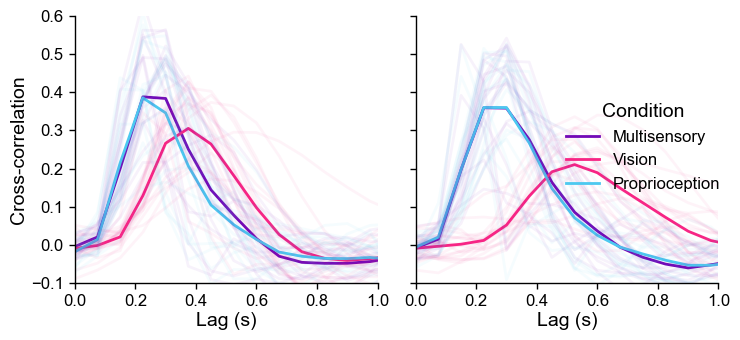

In [31]:
palette = {'Vision': "#F72585", 'Proprioception':  "#4CC9F0", 'Multisensory': "#7209B7"}
g = (so.Plot(ccgs[ccgs["model"] == "Data"], x="lag", y="correlation", color="Condition")
    .add(so.Line(), so.Agg())
    .add(so.Line(alpha=0.05), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .facet(col="vis_noise", 
    # row="model", order={"row": ["data", "optimal", "no_integration", "equal_integration"]}
           )
    .label(x="Lag (s)", y="Cross-correlation", title="")
    .limit(x=(-0.0, 1.0), y=(-0.1, 0.6))
    # .scale(color=so.Nominal({"vis": sns.color_palette("colorblind")[3], "prop": sns.color_palette("colorblind")[0], "multi": sns.color_palette("colorblind")[4]}))
    .scale(color=so.Nominal(palette))
    .layout(size=(7.5, 3.5))
)
g.show()

## CCG parameters (peak)

In [13]:
ccg_params = ccgs.groupby(["participant", "model", "Condition", "Visual target"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        'lag': g.loc[g['correlation'].idxmax(), 'lag']
    }),
    include_groups=False
).reset_index()

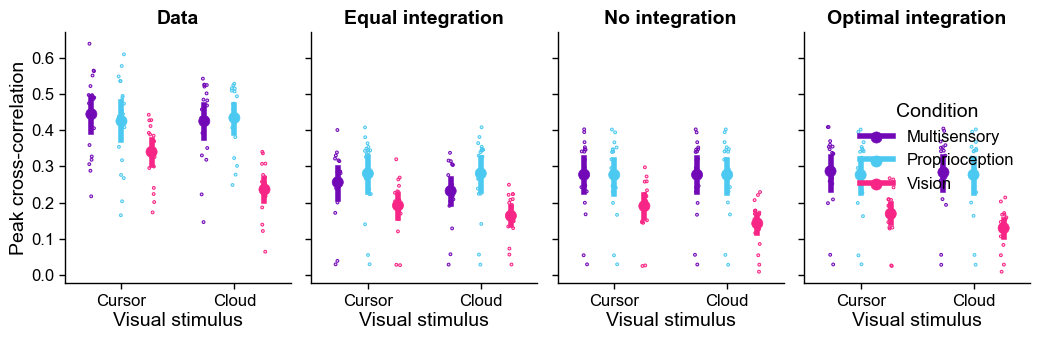

In [17]:
g = (so.Plot(ccg_params, x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model")
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    .layout(size=(10.5, 3.5))
    # .share(y=False)
)

g.show()

## Compare data and simulations in calibration phase


First, we load the model simulations for all participants

In [19]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]


In [20]:
df = df[df["time_within_trial"] > 3.0]

# replace 'value' with your measurement column name
pre_means = (
    df[df['phase'] == 'pre_cal']
    .groupby(['participant', 'type', 'vis_noise'])['tracking_error']
    .mean()
    .reset_index(name='pre_mean')
)

df = df.merge(pre_means, on=['participant', 'type', 'vis_noise'], how='left')
df['tracking_error'] = df['tracking_error'] - df['pre_mean']
# optional: handle groups with no pre_cal by filling
# df['tracking_error_centered'] = df['value'] - df['pre_mean'].fillna(0)

# add data to simulation dataframe
df["model"] = "data"

In [21]:
df_sim = pd.concat([df, df_sim]).reset_index(drop=True)

In [22]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

df_sim["model"] = df_sim["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

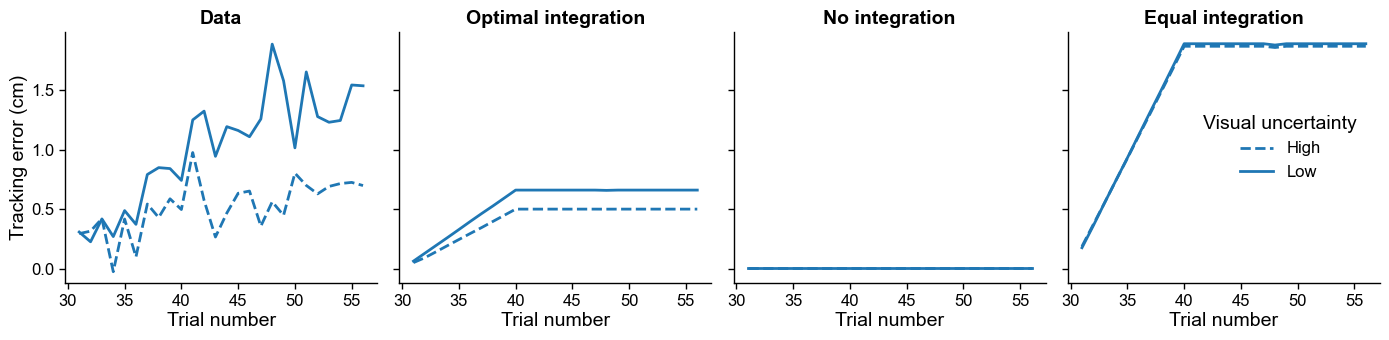

In [25]:
#  "Optimal integration", "No integration"

mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "model", "Visual uncertainty", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .median()
    .reset_index()
)


g = (
    so.Plot(
        # df_sim[
        #     (df_sim["phase"].isin(["calibration"]))
        #     & (df_sim["model"].isin(["Data", "Optimal integration", "No integration"]))
        #     # & (df_sim["participant"] == 182095555)
        # ],
        mean_df,
        x="trial_number",
        y="tracking_error",
        linestyle="Visual uncertainty",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Low": "-", "High": "--"}))
    .facet(col="model", order=["Data", "Optimal integration", "No integration", "Equal integration"])
    .layout(size=(14, 3.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.show()